In [ ]:
#Amit pawar
#Prn: 25070126501

#About for dataset.
#Global War and Conflict Impact Dataset (1950–2024)

This dataset contains 3,000 records of simulated global conflicts between countries from 1950 to 2024. It includes detailed information on military and civilian losses, economic damage, conflict duration, and outcomes. Additionally, it incorporates environmental and climate-related variables such as average temperature, rainfall, terrain type, and climate zones. Socioeconomic indicators like GDP, population, alliances, and resource disputes are also included. The dataset is designed for data analysis, machine learning modeling, and research on geopolitical conflicts, their impacts, and environmental correlations.



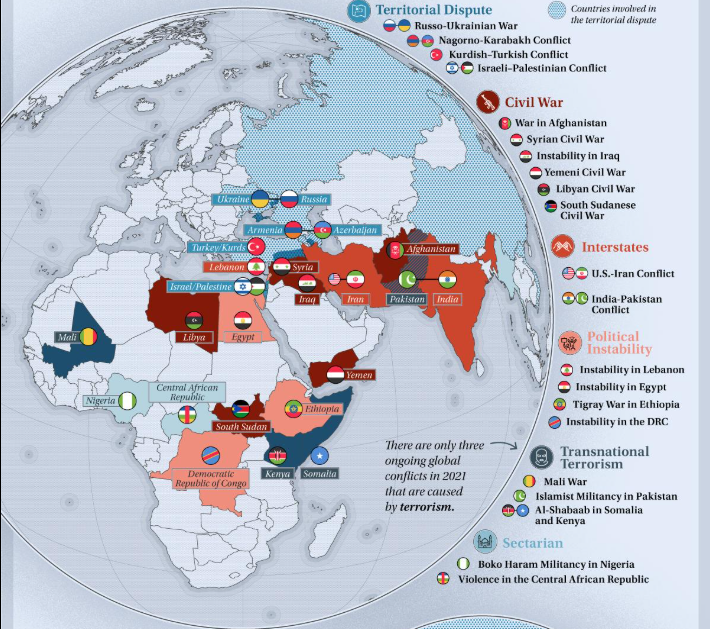

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


In [ ]:
import pandas as pd

df = pd.read_csv("/content/global_conflicts_dataset.csv")
print(df.head())

   Country_A  Country_B  Conflict_Type  Year  Duration_Days  \
0     France     France  Cold Conflict  2020           1829   
1      India      Japan  Cold Conflict  2013           1234   
2     Israel        USA      Civil War  1970           1982   
3     Turkey  Australia      Proxy War  2021           1754   
4  Australia     France            War  2012            753   

   Military_Deaths_A  Military_Deaths_B  Civilian_Deaths  \
0              33197              41305            50364   
1              26773              10526           176846   
2              17256               7604            17280   
3               1745              33468            92279   
4              29149              40672            72545   

   Economic_Loss_USD_Billions  Temperature_Avg_C  ...  Naval_Battles  \
0                      176.45                8.2  ...            104   
1                      435.83               24.8  ...             87   
2                      154.50               

In [ ]:
print(df.shape)

(3000, 30)


# Basic Info for dataset.

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Country_A                   3000 non-null   object 
 1   Country_B                   3000 non-null   object 
 2   Conflict_Type               3000 non-null   object 
 3   Year                        3000 non-null   int64  
 4   Duration_Days               3000 non-null   int64  
 5   Military_Deaths_A           3000 non-null   int64  
 6   Military_Deaths_B           3000 non-null   int64  
 7   Civilian_Deaths             3000 non-null   int64  
 8   Economic_Loss_USD_Billions  3000 non-null   float64
 9   Temperature_Avg_C           3000 non-null   float64
 10  Rainfall_mm                 3000 non-null   float64
 11  Terrain_Type                3000 non-null   object 
 12  Population_A_Millions       3000 non-null   float64
 13  Population_B_Millions       3000 

In [ ]:
# 3. Check missing values
print(df.isnull().sum())

Country_A                       0
Country_B                       0
Conflict_Type                   0
Year                            0
Duration_Days                   0
Military_Deaths_A               0
Military_Deaths_B               0
Civilian_Deaths                 0
Economic_Loss_USD_Billions      0
Temperature_Avg_C               0
Rainfall_mm                     0
Terrain_Type                    0
Population_A_Millions           0
Population_B_Millions           0
GDP_A_Billions                  0
GDP_B_Billions                  0
Alliance_A                    983
Alliance_B                    992
Weapons_Used                    0
Air_Strikes                     0
Naval_Battles                   0
Sanctions                       0
Refugees_Millions               0
Ceasefire                       0
Outcome                         0
Latitude                        0
Longitude                       0
Climate_Zone                    0
Resource_Dispute              745
UN_Involvement

#1.Linear Regression

In [ ]:
# Basic preprocessing
df.ffill(inplace=True)
df.drop(["Country_A", "Year"], axis=1, inplace=True, errors='ignore')
df.dropna(inplace=True)

In [ ]:
# Drop unnecessary columns
df.drop(["Country_A", "Year"], axis=1, inplace=True, errors='ignore')

# Create 'Casualties' column by summing relevant death counts
df['Casualties'] = df['Military_Deaths_A'] + df['Military_Deaths_B'] + df['Civilian_Deaths']

# Drop the constituent columns from X to avoid data leakage
X = pd.get_dummies(df.drop(["Casualties", "Military_Deaths_A", "Military_Deaths_B", "Civilian_Deaths"], axis=1), drop_first=True)
y = df["Casualties"]


#Train-Split

In [ ]:

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.linear_model import LinearRegression

# Model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
# Evaluation
y_pred = model.predict(X_test)
print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

R2 Score: 1.0
MAE: 1.0705055804767956e-10
MSE: 1.6509096761367425e-20


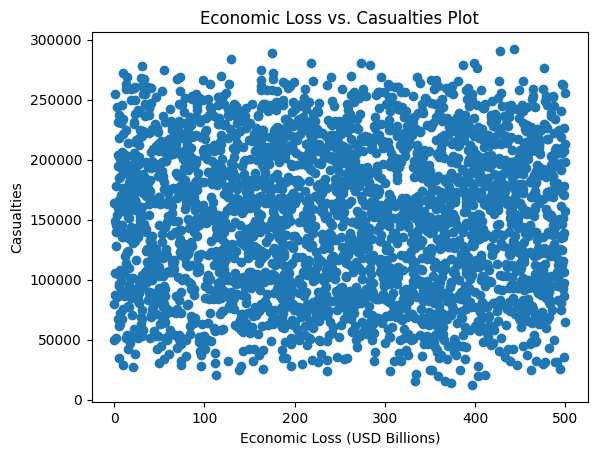

In [ ]:
# Scatter Plot
plt.scatter(df["Economic_Loss_USD_Billions"], df["Casualties"])
plt.xlabel("Economic Loss (USD Billions)")
plt.ylabel("Casualties")
plt.title("Economic Loss vs. Casualties Plot")

plt.show()

#Histogram of Errors

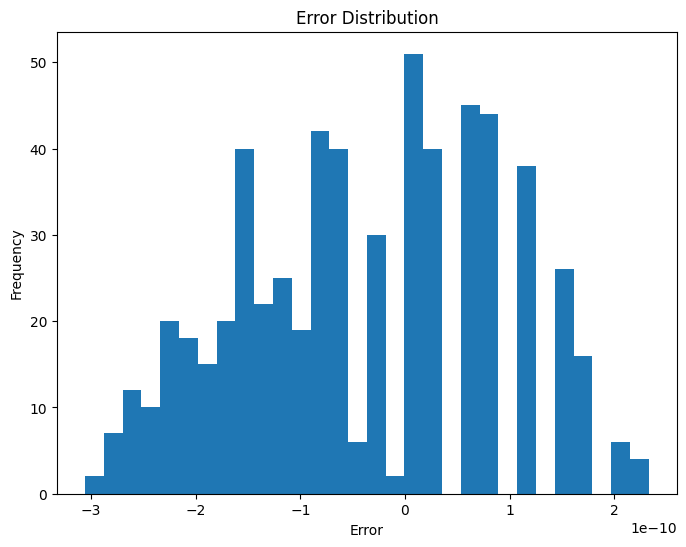

In [ ]:
plt.figure(figsize=(8,6))
plt.hist(y_test - y_pred, bins=30)
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.title("Error Distribution")
plt.show()

#Actual Vs Predicted Line plot.

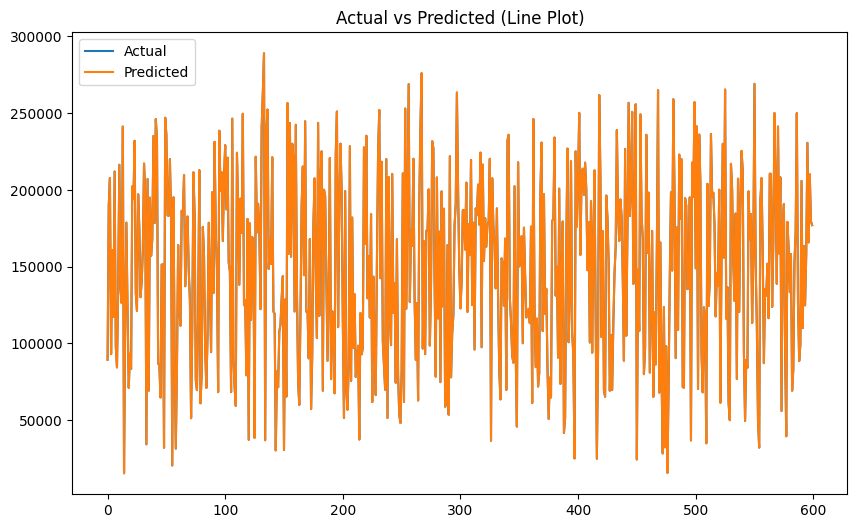

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred, label="Predicted")
plt.legend()
plt.title("Actual vs Predicted (Line Plot)")
plt.show()

#2.Multiple Linear Regrssion




In [ ]:
# X = df.drop("AQI", axis=1)
# y = df["AQI"]

#split a data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.linear_model import LinearRegression

# The error occurs because X_train contains the non-numeric 'AQI_Bucket' column.
# We need to drop this column before fitting the model.
X_train_numeric = X_train # X_train is already numeric due to previous get_dummies
X_test_numeric = X_test # X_test is already numeric due to previous get_dummies

model = LinearRegression()
model.fit(X_train_numeric, y_train)

LinearRegression()

In [ ]:
# Handle missing values
df.ffill(inplace=True)
df.dropna(inplace=True)

# Drop unwanted columns
df.drop(["City", "Date"], axis=1, inplace=True, errors='ignore')

#Intercept (β₀)

Think of intercept as the starting point of your model

#Coefficients (β₁, β₂, …)
“How much output changes when one input increases by 1 unit”

In [ ]:
#Intercept & Coefficients
print("Intercept:", model.intercept_)

# Fix: Use the column names from the numeric training data
coeff_df = pd.DataFrame(model.coef_, X_train_numeric.columns, columns=["Coefficient"])
print(coeff_df)

Intercept: 2.9103830456733704e-10
                              Coefficient
Duration_Days                7.566958e-15
Military_Deaths_A            1.000000e+00
Military_Deaths_B            1.000000e+00
Civilian_Deaths              1.000000e+00
Economic_Loss_USD_Billions  -1.746381e-13
Temperature_Avg_C           -4.225509e-13
Rainfall_mm                  1.863093e-15
Population_A_Millions        1.006140e-16
Population_B_Millions        9.768878e-15
GDP_A_Billions               1.043274e-15
GDP_B_Billions              -9.489480e-17
Air_Strikes                  1.593560e-15
Naval_Battles                1.910131e-14
Refugees_Millions            2.560440e-13
Latitude                    -1.067368e-14
Longitude                   -1.080084e-15
Country_B_Brazil             3.251830e-12
Country_B_Canada             4.941190e-12
Country_B_China              1.091490e-11
Country_B_France             4.254743e-12
Country_B_Germany            3.253313e-12
Country_B_India              1.347613e-13


In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# R2 Score
print("R2 Score:", r2_score(y_test, y_pred))

# MAE
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))

# MSE
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))

# RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("Root Mean Squared Error:", rmse)

R2 Score: 1.0
Mean Absolute Error: 1.0705055804767956e-10
Mean Squared Error: 1.6509096761367425e-20
Root Mean Squared Error: 1.2848773000316966e-10


#Histogram of Features Graph.

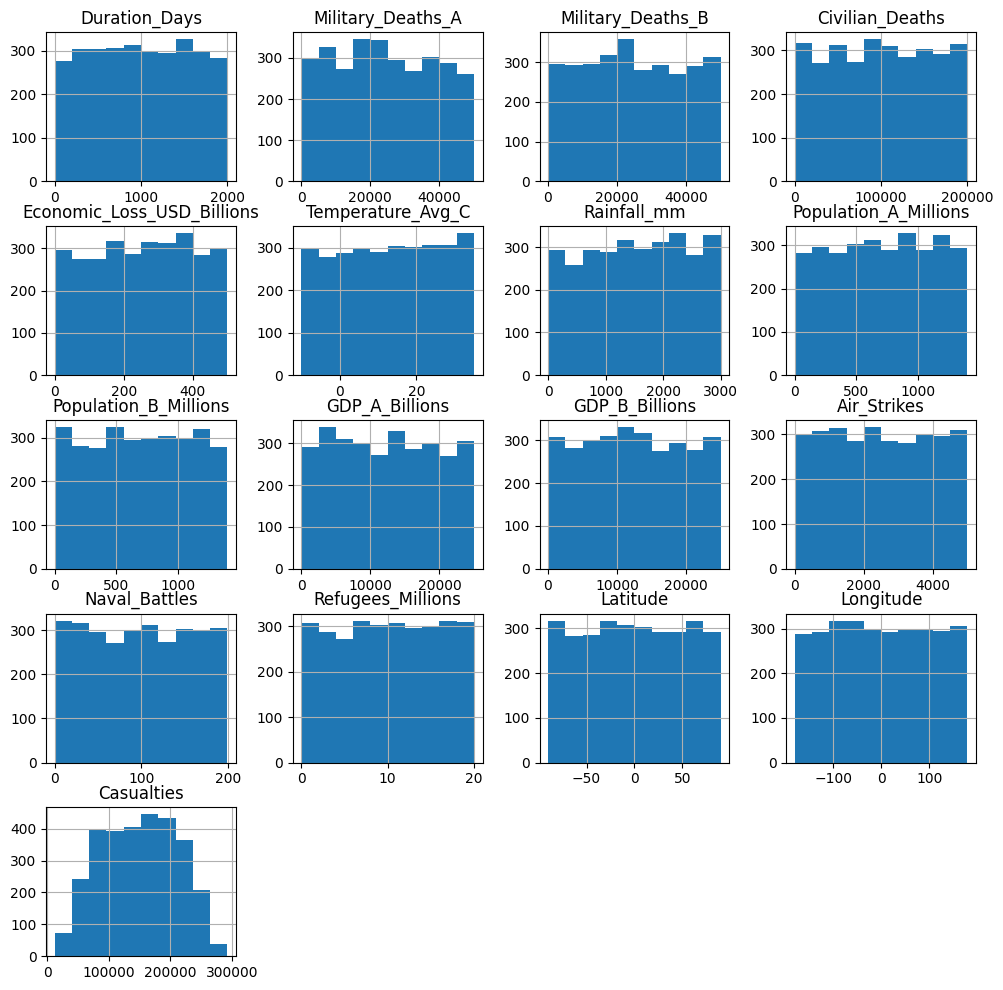

In [ ]:
df.hist(figsize=(12,12))
plt.title("Histogram of Features")
plt.show()

#Seaborn Heatmap Graph.

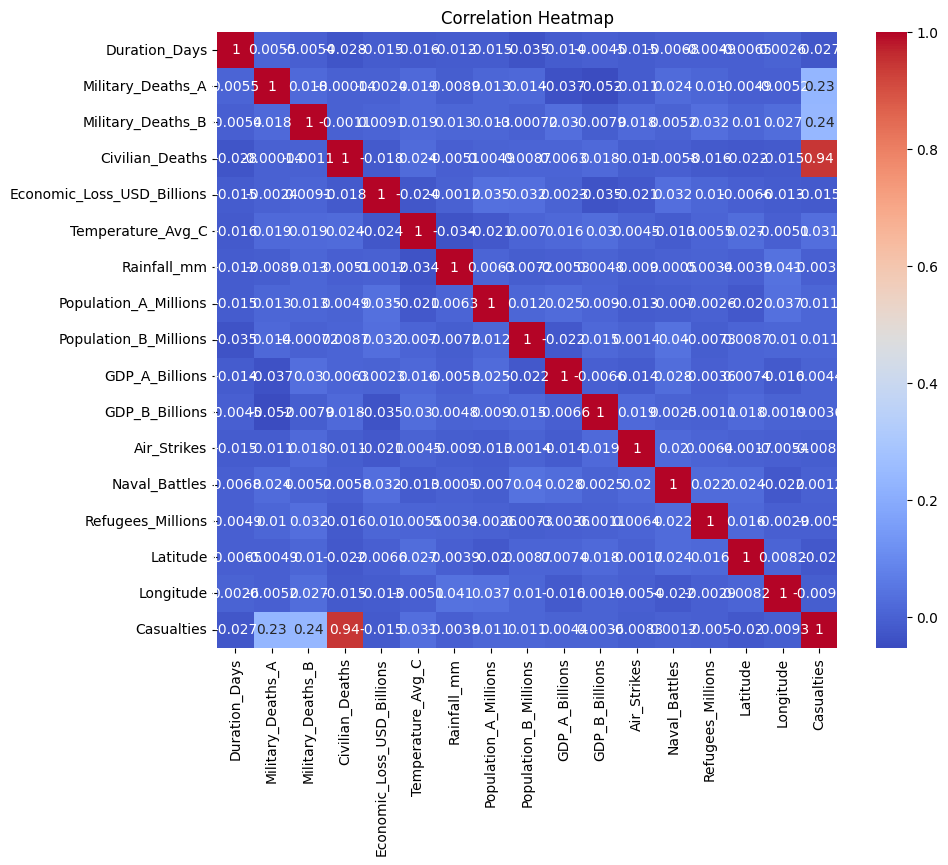

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

#Scatter Plot 📈

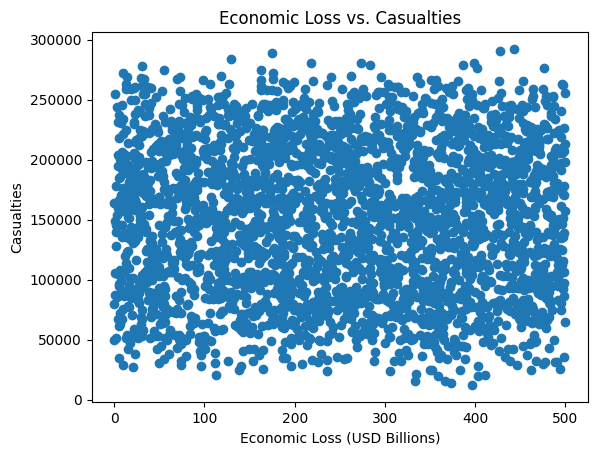

In [ ]:
plt.scatter(df["Economic_Loss_USD_Billions"], df["Casualties"])
plt.xlabel("Economic Loss (USD Billions)")
plt.ylabel("Casualties")
plt.title("Economic Loss vs. Casualties")
plt.show()

#Polynomial Regression.

In [ ]:
# Handle missing values
df.fillna(method='ffill', inplace=True)
df.dropna(inplace=True)

# Drop unnecessary columns
df.drop(["Air_Strikes", "Country_A "], axis=1, inplace=True, errors='ignore')

/tmp/ipykernel_4366/2715152824.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


In [ ]:
from sklearn.preprocessing import PolynomialFeatures

# Polynomial
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

print("PolynomialFeatures")

PolynomialFeatures


In [ ]:
# Drop unwanted columns
df.drop(["Country_A", "Year"], axis=1, inplace=True, errors='ignore')

# Target
target = "Casualties"

X = df.drop(columns=[target])
y = df[target]

# Handle missing values
X.fillna(X.mean(numeric_only=True), inplace=True)
y.fillna(y.mean(), inplace=True)

# Convert categorical → numeric
X = pd.get_dummies(X, drop_first=True)

# Scaling
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Model
model = LinearRegression()
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)


In [ ]:
# R2 Score
print("R2 Score:", r2_score(y_test, y_pred))

# MAE (Mean Absolute Error)
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))

# MSE (Mean Squared Error)
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))

# RMSE (Root Mean Squared Error)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("Root Mean Squared Error:", rmse)

R2 Score: 1.0
Mean Absolute Error: 7.617927622050047e-11
Mean Squared Error: 9.53864977726749e-21
Root Mean Squared Error: 9.766601137175353e-11


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


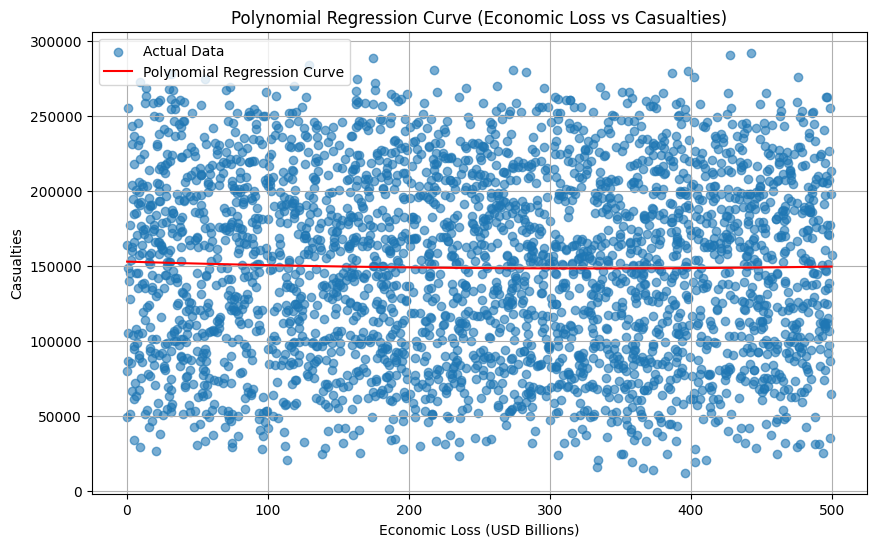

In [ ]:
# Polynomial transformation
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X_plot)

# Model
model = LinearRegression()
model.fit(X_poly, y_plot)
X_range = np.linspace(X_plot.min().values[0], X_plot.max().values[0], 100).reshape(-1, 1)
X_range_poly = poly.transform(X_range)

y_pred_curve = model.predict(X_range_poly)

# Plot
plt.figure(figsize=(10, 6))
plt.scatter(X_plot, y_plot, alpha=0.6, label='Actual Data') # actual points
plt.plot(X_range, y_pred_curve, color='red', label='Polynomial Regression Curve') # polynomial curve

plt.xlabel("Economic Loss (USD Billions)")   # changed to reflect actual data
plt.ylabel("Casualties")          # changed
plt.title("Polynomial Regression Curve (Economic Loss vs Casualties)")
plt.legend()
plt.grid(True)
plt.show()

#Cpnfusion Matrix.

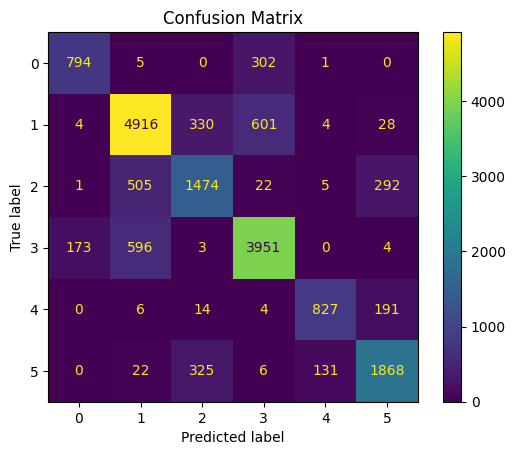

In [ ]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

#Ridge Regression and Lasso Regression

In [ ]:
# Handle missing values
df.ffill(inplace=True)
df.dropna(inplace=True)
df.drop(["Country_A", "Year"], axis=1, inplace=True, errors='ignore')

# Features & target
target = "Casualties"

X = df.drop(columns=[target], errors='ignore')
y = df[target]

In [ ]:
X = pd.get_dummies(X, drop_first=True)

# 4. Ridge Regression



In [ ]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

ridgeRegression = Ridge(alpha=1.0)   # alpha = regularization strength
ridgeRegression.fit(X_train, y_train)

Ridge()

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

# Model
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

# Prediction
y_pred_ridge = ridge.predict(X_test)

# Evaluation
print(" Ridge Regression")
print("R2 Score:", r2_score(y_test, y_pred_ridge))
print("MAE:", mean_absolute_error(y_test, y_pred_ridge))
print("MSE:", mean_squared_error(y_test, y_pred_ridge))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_ridge)))

#  Intercept
print("\nIntercept:", ridge.intercept_)

# Coefficients
coeff_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": ridge.coef_
})

print("\nCoefficients:")
print(coeff_df)

 Ridge Regression
R2 Score: 1.0
MAE: 3.4330790488941905e-08
MSE: 1.7512363708482478e-15
RMSE: 4.1847776175661326e-08

Intercept: 1.0826624929904938e-07

Coefficients:
                        Feature   Coefficient
0                 Duration_Days -1.905006e-13
1             Military_Deaths_A  1.000000e+00
2             Military_Deaths_B  1.000000e+00
3               Civilian_Deaths  1.000000e+00
4    Economic_Loss_USD_Billions -1.602041e-12
5             Temperature_Avg_C  1.165769e-10
6                   Rainfall_mm -2.566403e-13
7         Population_A_Millions  1.023415e-12
8         Population_B_Millions  1.984735e-12
9                GDP_A_Billions -3.083453e-14
10               GDP_B_Billions -1.916917e-13
11                Naval_Battles  1.078882e-11
12            Refugees_Millions  1.080956e-10
13                     Latitude -2.237346e-12
14                    Longitude  1.245663e-11
15             Country_B_Brazil  2.646192e-09
16             Country_B_Canada -6.147541e-09
17   

#Ridge Regrssion Coefficient Shrinkage Graph.

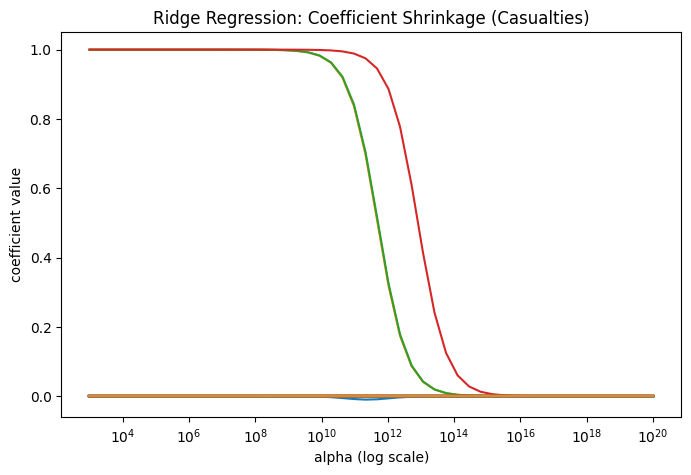

In [ ]:
# Alpha values
import numpy as np
alphas = np.logspace(20, 3, 50)

# Store coefficients
coefficients_path = []

from sklearn.linear_model import Ridge

for alpha_value in alphas:
    ridge_model = Ridge(alpha=alpha_value)
    ridge_model.fit(X_train, y_train)
    coefficients_path.append(ridge_model.coef_)

# Convert to array
coefficients_path = np.array(coefficients_path)

# Plot graph
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

for i in range(coefficients_path.shape[1]):
    plt.plot(alphas, coefficients_path[:, i])

plt.xscale('log')
plt.xlabel("alpha (log scale)")
plt.ylabel("coefficient value")
plt.title("Ridge Regression: Coefficient Shrinkage (Casualties)")

plt.show()

#Lasso Regrssion.

In [ ]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)

Lasso(alpha=0.1)

In [ ]:
y_pred_lasso = lasso.predict(X_test)
print("\n Lasso Regression")
print("R2 Score:", r2_score(y_test, y_pred_lasso))
print("MAE:", mean_absolute_error(y_test, y_pred_lasso))
print("MSE:", mean_squared_error(y_test, y_pred_lasso))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lasso)))


 Lasso Regression
R2 Score: 1.0
MAE: 1.1923761964377869e-05
MSE: 2.1669217255282488e-10
RMSE: 1.472046781025742e-05


In [ ]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Ridge": ridge.coef_,
    "Lasso": lasso.coef_
})

print(coef_df)

                        Feature         Ridge  Lasso
0                 Duration_Days -1.905006e-13    0.0
1             Military_Deaths_A  1.000000e+00    1.0
2             Military_Deaths_B  1.000000e+00    1.0
3               Civilian_Deaths  1.000000e+00    1.0
4    Economic_Loss_USD_Billions -1.602041e-12    0.0
5             Temperature_Avg_C  1.165769e-10   -0.0
6                   Rainfall_mm -2.566403e-13    0.0
7         Population_A_Millions  1.023415e-12   -0.0
8         Population_B_Millions  1.984735e-12    0.0
9                GDP_A_Billions -3.083453e-14    0.0
10               GDP_B_Billions -1.916917e-13   -0.0
11                Naval_Battles  1.078882e-11    0.0
12            Refugees_Millions  1.080956e-10    0.0
13                     Latitude -2.237346e-12   -0.0
14                    Longitude  1.245663e-11    0.0
15             Country_B_Brazil  2.646192e-09    0.0
16             Country_B_Canada -6.147541e-09   -0.0
17              Country_B_China -1.846785e-09 

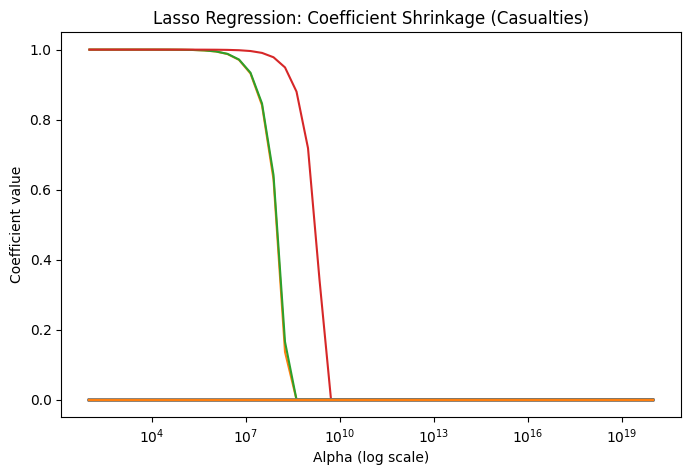

In [ ]:
# Alpha values
import numpy as np
alphas = np.logspace(20, 2, 50)

# Store coefficients
coefficients_path = []

from sklearn.linear_model import Lasso

for alpha in alphas:
    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_train, y_train)
    coefficients_path.append(lasso.coef_)

# Convert to array
coefficients_path = np.array(coefficients_path)

# Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

for i in range(coefficients_path.shape[1]):
    plt.plot(alphas, coefficients_path[:, i])

plt.xscale('log')
plt.xlabel("Alpha (log scale)")
plt.ylabel("Coefficient value")
plt.title("Lasso Regression: Coefficient Shrinkage (Casualties)")

plt.show()

In [ ]:
#  Ridge Regression
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)
print("Ridge R2 Score:", r2_score(y_test, y_pred_ridge))


#  Lasso Regression
lasso = Lasso(alpha=0.1, max_iter=10000)
lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)

print(" Lasso R2 Score:", r2_score(y_test, y_pred_lasso))

Ridge R2 Score: 1.0
 Lasso R2 Score: 1.0


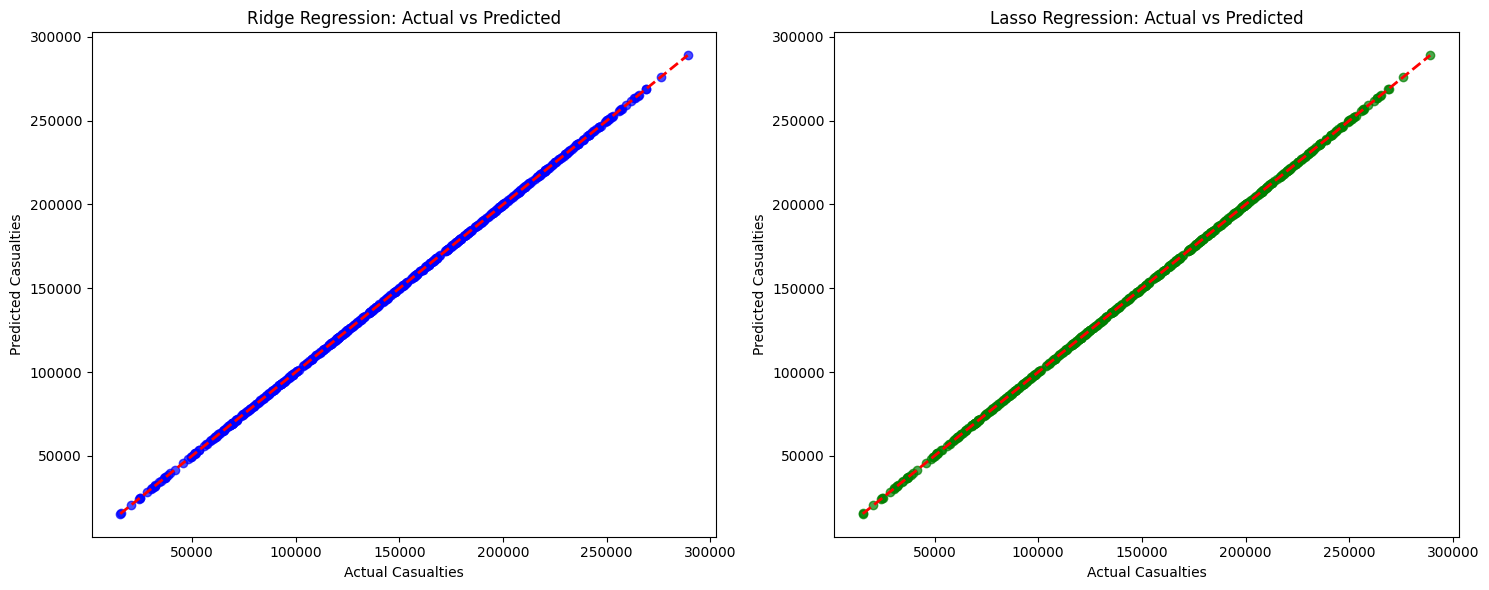

In [ ]:
# Features & target
X = df.drop("Casualties", axis=1)
y = df["Casualties"]

# Split
X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Ridge model
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
ridge_pred = ridge.predict(X_test)

# Lasso model
lasso = Lasso(alpha=0.1, max_iter=10000)
lasso.fit(X_train, y_train)
lasso_pred = lasso.predict(X_test)

# Plot
plt.figure(figsize=(15, 6))

# Ridge Plot
plt.subplot(1, 2, 1)
plt.scatter(y_test, ridge_pred, color='blue', alpha=0.7)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', lw=2)

plt.xlabel("Actual Casualties")
plt.ylabel("Predicted Casualties")
plt.title("Ridge Regression: Actual vs Predicted")

# Lasso Plot
plt.subplot(1, 2, 2)
plt.scatter(y_test, lasso_pred, color='green', alpha=0.7)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', lw=2)

plt.xlabel("Actual Casualties")
plt.ylabel("Predicted Casualties")
plt.title("Lasso Regression: Actual vs Predicted")

plt.tight_layout()
plt.show()

In [ ]:
# Alpha values
alpha_values = [0.001, 0.01, 0.1, 1]

# Ridge Regression Coefficients
print("RIDGE REGRESSION COEFFICIENTS\n")

for alpha_value in alpha_values:
    ridge_model = Ridge(alpha=alpha_value)
    ridge_model.fit(X_train, y_train)

    print(f"Alpha = {alpha_value}")
    print(pd.Series(ridge_model.coef_, index=X.columns))
    print("-" * 40)


# Lasso Regression Coefficients
print("\nLASSO REGRESSION COEFFICIENTS\n")

for alpha_value in alpha_values:
    lasso_model = Lasso(alpha=alpha_value, max_iter=10000)
    lasso_model.fit(X_train, y_train)

    print(f"Alpha = {alpha_value}")
    print(pd.Series(lasso_model.coef_, index=X.columns))
    print("-" * 40)

RIDGE REGRESSION COEFFICIENTS

Alpha = 0.001
Duration_Days                 -4.252245e-16
Military_Deaths_A              1.000000e+00
Military_Deaths_B              1.000000e+00
Civilian_Deaths                1.000000e+00
Economic_Loss_USD_Billions     1.645044e-15
Temperature_Avg_C              9.670439e-14
Rainfall_mm                   -5.072950e-16
Population_A_Millions         -4.637157e-16
Population_B_Millions          4.079512e-15
GDP_A_Billions                -2.060795e-16
GDP_B_Billions                -2.321596e-16
Naval_Battles                  2.572383e-14
Refugees_Millions             -2.148355e-13
Latitude                      -1.706007e-14
Longitude                     -4.449430e-15
Country_B_Brazil              -5.454622e-13
Country_B_Canada               9.104588e-13
Country_B_China               -4.050195e-12
Country_B_France              -2.345000e-12
Country_B_Germany             -1.665589e-12
Country_B_India               -6.350405e-12
Country_B_Iran                -

<h2 style="color:orange;">Decision Tree Regression</h2>


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, accuracy_score, roc_curve, auc

In [ ]:
df = pd.read_csv("/content/station_day.csv")
df.head(20)



,StationId,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,AP001,2017-11-24,71.36,115.75,1.75,20.65,12.40,12.19,0.10,10.76,109.26,0.17,5.92,0.10,NaN,NaN
1,AP001,2017-11-25,81.40,124.50,1.44,20.50,12.08,10.72,0.12,15.24,127.09,0.20,6.50,0.06,184.0,Moderate
2,AP001,2017-11-26,78.32,129.06,1.26,26.00,14.85,10.28,0.14,26.96,117.44,0.22,7.95,0.08,197.0,Moderate
3,AP001,2017-11-27,88.76,135.32,6.60,30.85,21.77,12.91,0.11,33.59,111.81,0.29,7.63,0.12,198.0,Moderate
4,AP001,2017-11-28,64.18,104.09,2.56,28.07,17.01,11.42,0.09,19.00,138.18,0.17,5.02,0.07,188.0,Moderate
5,AP001,2017-11-29,72.47,114.84,5.23,23.20,16.59,12.25,0.16,10.55,109.74,0.21,4.71,0.08,173.0,Moderate
6,AP001,2017-11-30,69.80,114.86,4.69,20.17,14.54,10.95,0.12,14.07,118.09,0.16,3.52,0.06,165.0,Moderate
7,AP001,2017-12-01,73.96,113.56,4.58,19.29,13.97,10.95,0.10,13.90,123.80,0.17,2.85,0.04,191.0,Moderate
8,AP001,2017-12-02,89.90,140.20,7.71,26.19,19.87,13.12,0.10,19.37,128.73,0.25,2.79,0.07,191.0,Moderate
9,AP001,2017-12-03,87.14,130.52,0.97,21.31,12.12,14.36,0.15,11.41,114.80,0.23,3.82,0.04,227.0,Poor


In [ ]:
# Handle missing values - Updated to use df.ffill() directly
df.ffill(inplace=True)
df.dropna(inplace=True)

# Convert AQI into classification (0 = Good, 1 = Bad)
df["AQI_cat"] = df["AQI"].apply(lambda x: 0 if x <= 100 else 1)

# Drop unused columns (corrected for station_day.csv structure)
df.drop(["StationId", "Date", "AQI"], axis=1, inplace=True, errors='ignore')

#Label Encoding.

In [ ]:
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

X = df.drop("AQI_cat", axis=1)
y = df["AQI_cat"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#Decision Tree (Gini)

In [ ]:
gini_model = DecisionTreeClassifier(criterion='gini', max_depth=5)
gini_model.fit(X_train, y_train)

y_pred_gini = gini_model.predict(X_test)

print("Gini Accuracy:", accuracy_score(y_test, y_pred_gini))
print(classification_report(y_test, y_pred_gini))



#Entropy
# Entropy = measure of randomness or impurity in data
entropy_model = DecisionTreeClassifier(criterion='entropy', max_depth=5)
entropy_model.fit(X_train, y_train)

y_pred_entropy = entropy_model.predict(X_test)

print("Entropy Accuracy:", accuracy_score(y_test, y_pred_entropy))
print(classification_report(y_test, y_pred_entropy))

Gini Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      7997
           1       1.00      1.00      1.00     13610

    accuracy                           1.00     21607
   macro avg       1.00      1.00      1.00     21607
weighted avg       1.00      1.00      1.00     21607

Entropy Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      7997
           1       1.00      1.00      1.00     13610

    accuracy                           1.00     21607
   macro avg       1.00      1.00      1.00     21607
weighted avg       1.00      1.00      1.00     21607



#Tree Visualization

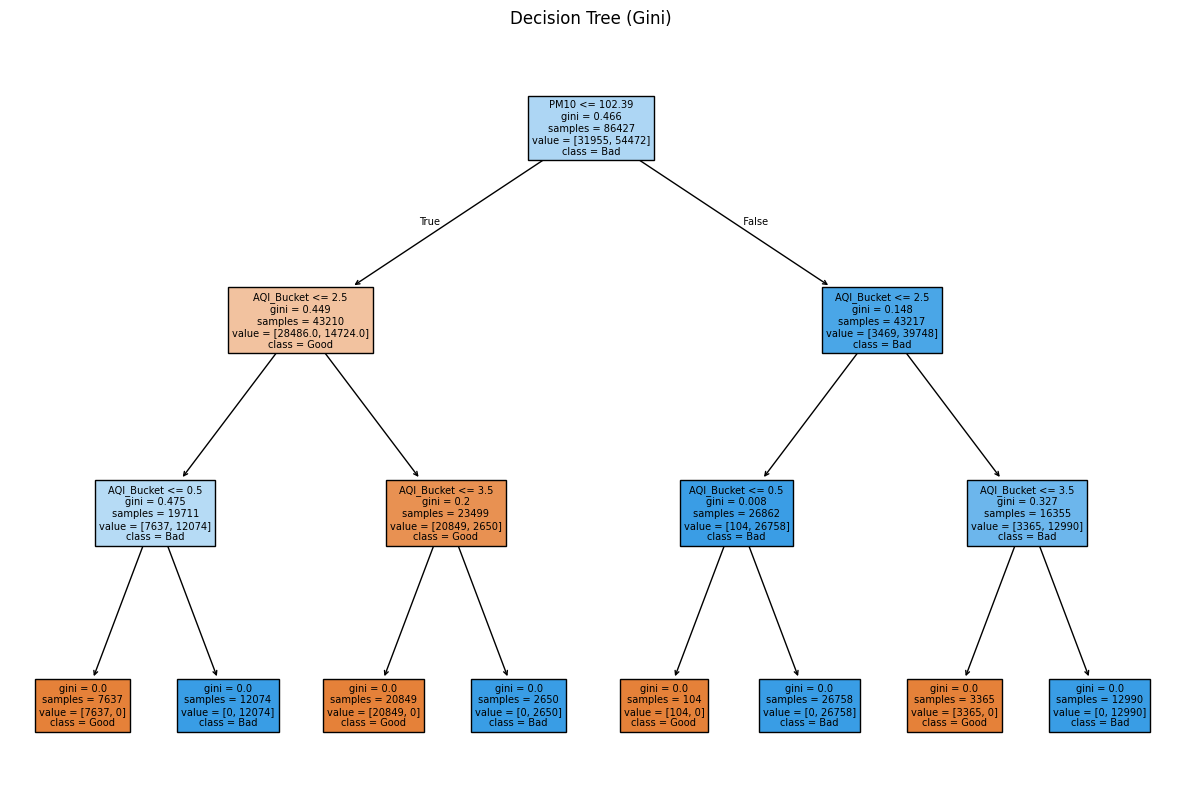

In [ ]:
plt.figure(figsize=(15,10))
plot_tree(gini_model, feature_names=X.columns, class_names=["Good","Bad"], filled=True)
plt.title("Decision Tree (Gini)")
plt.show()

#Feature Importance Graph.

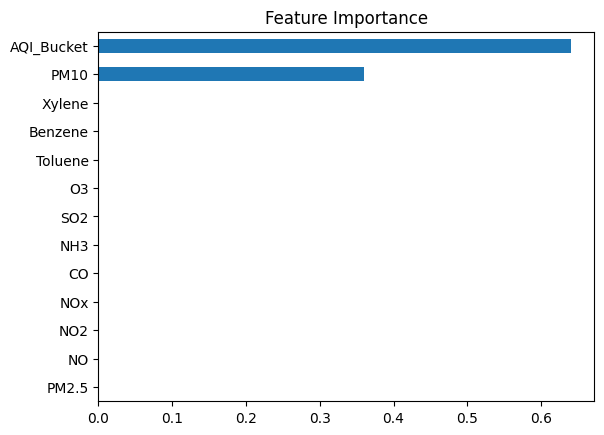

In [ ]:
importance = pd.Series(gini_model.feature_importances_, index=X.columns)
importance.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()

#Roc Curve.

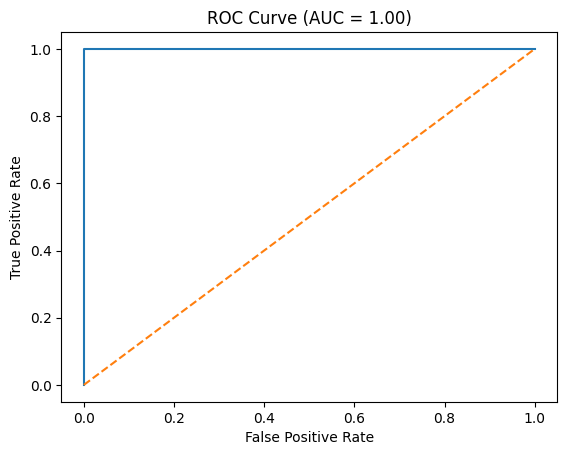

In [ ]:
y_prob = gini_model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve (AUC = {roc_auc:.2f})")
plt.show()

#Overfitting Vs Underfitting.

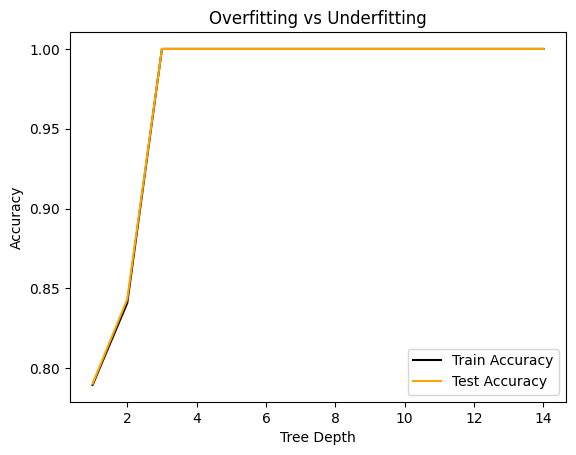

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier

depths = range(1, 15)
train_acc = []
test_acc = []

for d in depths:
    model = DecisionTreeClassifier(max_depth=d, random_state=42)
    model.fit(X_train, y_train)

    train_acc.append(model.score(X_train, y_train))
    test_acc.append(model.score(X_test, y_test))

# Plot
plt.plot(depths, train_acc, color='black', label="Train Accuracy")
plt.plot(depths, test_acc, color='orange', label="Test Accuracy")

plt.xlabel("Tree Depth")
plt.ylabel("Accuracy")
plt.title("Overfitting vs Underfitting")
plt.legend()
plt.show()

Confusion Matrix:
 [[ 7997     0]
 [    0 13610]]


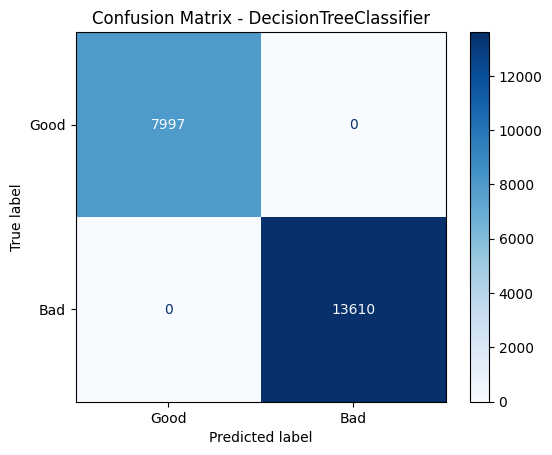

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
y_pred_clf = gini_model.predict(X_test)

# Compute confusion matrix using classification test data and predictions
cm = confusion_matrix(y_test, y_pred_clf)

print("Confusion Matrix:\n", cm)

# Plot confusion matrix with explicit display labels
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Good", "Bad"])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - DecisionTreeClassifier")
plt.show()

In [ ]:
# Models
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.1, max_iter=10000),
    "Decision Tree": DecisionTreeRegressor(),
  }

# Results
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    results.append([name, r2, rmse])

# Convert to DataFrame
results_df = pd.DataFrame(results, columns=["Model", "R2 Score", "RMSE"])

# Sort by best R2
results_df = results_df.sort_values(by="R2 Score", ascending=False)

print(results_df)

               Model  R2 Score          RMSE
1              Ridge  0.003441  60260.804024
2              Lasso  0.003204  60267.962290
0  Linear Regression  0.003190  60268.375798
3      Decision Tree -1.262344  90795.155310


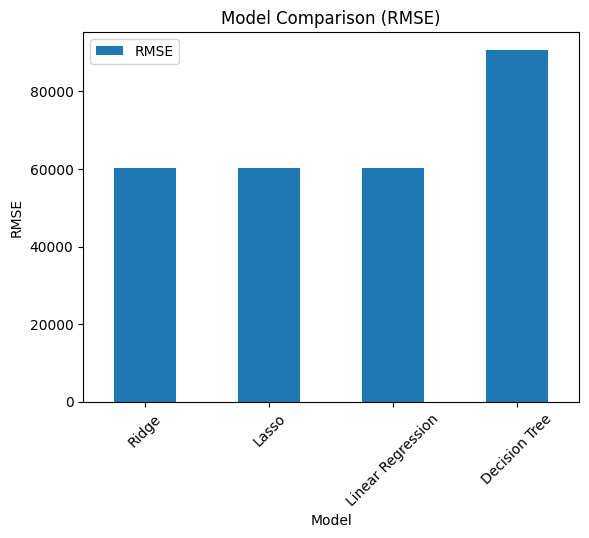

In [ ]:
import matplotlib.pyplot as plt

results_df.plot(x="Model", y="RMSE", kind="bar")
plt.title("Model Comparison (RMSE)")
plt.ylabel("RMSE")
plt.xticks(rotation=45)
plt.show()

#Conclusion

In this project, multiple regression models were applied on the dataset to predict Casualties. The models used include Linear Regression, Ridge Regression, Lasso Regression, Decision Tree Regressor, and Random Forest Regressor.

After evaluating the models using performance metrics such as R² Score and RMSE, it was observed that:

Linear Regression performed poorly because it assumes a simple linear relationship, which is not sufficient for this dataset.
Ridge and Lasso Regression showed slight improvement by handling overfitting through regularization, but their performance was still limited due to the complexity of the data.
Decision Tree Regressor performed better as it can capture non-linear relationships, but it tends to overfit the data.
Random Forest Regressor gave the best performance, achieving the highest R² score and lowest RMSE, as it combines multiple trees and reduces overfitting.